

```
# This is formatted as code
```

# 📊 Kuis 1 Machine Learning - EDA & Preprocessing
Soal kuis berbasis dataset TI-3B. Buat dataset TI-3B dengan fitur sebagai berikut: nama lengkap, jenis kelamin, kota asal, tinggi badan(cm), asal kelas, target IP semester 5, warna kesukaan, hobi, film favorit, warna favorit, genre musik, idola, kota favorit, makanan favorit, minuman favorit, negara yang ingin dikunjungi.
Silakan kerjakan langsung di Colab dengan mengisi kode dan jawabanmu.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/Atherizz/ML_2026/main/kuis/3b.csv'
df = pd.read_csv(url)

# Tampilkan 10 data awal
df.head()

,no,nama_lengkap,jenis_kelamin,kota_asal,tinggi_badan_(cm),asal_kelas,target_ip_smt_5,warna_kesukaan,hobi,film_fav,genre_musik,idola,kota_fav,makanan_fav,minuman_fav,negara_yang_ingin_dikunjungi
0,1,Alfreda Dhaifullah Mahezwara,L,Malang,172,2C,4,Red Marron,Main ML,The Shadow Edge,Britpop,Jackable,"malang,batu",Nasi Goreng,Es Teler,China
1,2,Angga Saputra Ramadhan,L,Probolinggo,163,2B,4,Putih,Sepak Bola,Semua,Electropop,Neymar Jr,Malang,Ayam Geprek,Capuccino,Thailand
2,3,Ardhan Dikri Achmad Fahrudin,L,Malang,172,2H,4,Biru,Basket,Toy Story,Pop,Messi,Labuan Bajo,Tahu Telor,Hot V60,Swiss
3,4,Arjuna Carly Dhymas Mahendra,L,Sidoarjo,165,2B,4,Biru,Basket,Seven,Rock,Ronaldo,Bandung,Sate Ayam,Air Mineral,Swiss
4,5,Arya Ramadhan,L,Malang,175,2G,4,Ungu,Berenang,Lucifer (2016-2021)`,Pop,Diana Rider,Malang,Oyi Buttermilk,KAPITEN,UK


## Soal 1
Hitung rata-rata tinggi badan mahasiswa **yang asal kotanya sama dengan kamu**.

- Bersihkan data asal kota dulu, jika ada data yang berisi "kota madiun", "kabupaten malang" bersihkan hingga hanya menjadi "madiun" dan "malang"
- Bandingkan tinggi badanmu dengan rata-rata kota asal.
- Apakah kamu lebih tinggi atau lebih rendah dari rata-rata tersebut?

In [3]:
# Jawaban Soal 1
# 1. Bersihkan data kota asal
df['kota_asal_clean'] = (
    df['kota_asal'].astype(str).str.lower()
    .str.replace('kota ', '', regex=False)
    .str.replace('kabupaten ', '', regex=False)
    .str.replace('kab. ', '', regex=False)
    .str.strip()
)

# 2. Ambil data diri dan hitung rata-rata kota asal
tb_saya = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'tinggi_badan_(cm)'].values[0]
rata_kota = df[df['kota_asal_clean'] == 'malang']['tinggi_badan_(cm)'].mean()

# 3. Hasil komparasi
status = "lebih tinggi" if tb_saya > rata_kota else "lebih rendah"
print(f"Rata-rata TB asal kota Malang : {rata_kota:.2f} cm")
print(f"Tinggi badan saya ({tb_saya} cm) : {status} dari rata-rata kota asal.")

Rata-rata TB asal kota Malang : 172.43 cm
Tinggi badan saya (180 cm) : lebih tinggi dari rata-rata kota asal.


## Soal 2
Kolom **Target IP semester 5 ini** memiliki variasi format (angka, teks, koma/titik).

- Bersihkan kolom menjadi numerik.
- Lakukan normalisasi Min-Max.
- Berapa nilai normalisasi IPS target kamu sendiri?

In [4]:
# Jawaban Soal 2
from sklearn.preprocessing import MinMaxScaler

# 1. Bersihkan kolom menjadi numerik
df['target_ip_clean'] = (
    df['target_ip_smt_5'].astype(str)
    .str.replace(',', '.', regex=False)
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

# 2. Normalisasi Min-Max
scaler = MinMaxScaler()
df['target_ip_norm'] = scaler.fit_transform(df[['target_ip_clean']])

# 3. Nilai normalisasi sendiri
ip_asli = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'target_ip_clean'].values[0]
ip_norm = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'target_ip_norm'].values[0]
print(f"Target IP semester 5 asli : {ip_asli}")
print(f"Nilai normalisasi Min-Max : {ip_norm:.4f}")


Target IP semester 5 asli : 4.0
Nilai normalisasi Min-Max : 0.0000


## Soal 3
Lakukan **Label Encoding** pada kolom **Warna kesukaan**.

- Tampilkan hasil encoding warna kesukaanmu sendiri.
- Apakah warnamu termasuk kode terkecil, terbesar, atau di tengah?

In [5]:
# Jawaban Soal 3
from sklearn.preprocessing import LabelEncoder

# 1. Bersihkan teks warna dan Label Encoding
df['warna_clean'] = df['warna_kesukaan'].astype(str).str.strip().str.title()
le = LabelEncoder()
df['warna_encoded'] = le.fit_transform(df['warna_clean'])

# 2. Posisi kode warna kesukaan sendiri
kode_saya = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'warna_encoded'].values[0]
warna_saya = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'warna_clean'].values[0]
min_k, max_k = df['warna_encoded'].min(), df['warna_encoded'].max()

posisi = "terkecil" if kode_saya == min_k else ("terbesar" if kode_saya == max_k else "di tengah")
print(f"Warna: '{warna_saya}' -> Kode: {kode_saya} (Rentang kode: {min_k} s.d. {max_k})")
print(f"Posisi: {posisi}")


Warna: 'Biru' -> Kode: 1 (Rentang kode: 0 s.d. 11)
Posisi: di tengah


## Soal 4
Kelompokkan data berdasarkan **Jenis kelamin**.

- Hitung rata-rata tinggi badan tiap kelompok.
- Bandingkan tinggi badanmu dengan rata-rata kelompokmu.

In [6]:
# Jawaban Soal 4
# 1. Kelompokkan berdasarkan jenis kelamin dan hitung rata-rata
rata_jk = df.groupby(df['jenis_kelamin'].str.strip().str.upper())['tinggi_badan_(cm)'].mean()

# 2. Komparasi dengan kelompok jenis kelamin sendiri (L)
tb_saya = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'tinggi_badan_(cm)'].values[0]
rata_l = rata_jk['L']
status = "lebih tinggi" if tb_saya > rata_l else "lebih rendah"

print("Rata-rata TB tiap kelompok:\n", rata_jk.round(2))
print(f"\nTB saya ({tb_saya} cm) : {status} dari rata-rata kelompok Laki-laki ({rata_l:.2f} cm).")


Rata-rata TB tiap kelompok:
 jenis_kelamin
L    171.89
P    157.86
Name: tinggi_badan_(cm), dtype: float64

TB saya (180 cm) : lebih tinggi dari rata-rata kelompok Laki-laki (171.89 cm).


## Soal 5 (pilih 2 fitur dari fitur yang ada)
Selanjutnya buat bar chart distribusi (misal)**Makanan favorit dan minuman favorit**.

- Dari grafik tersebut, apakah makanan dan minuman favoritmu termasuk dominan atau minoritas?

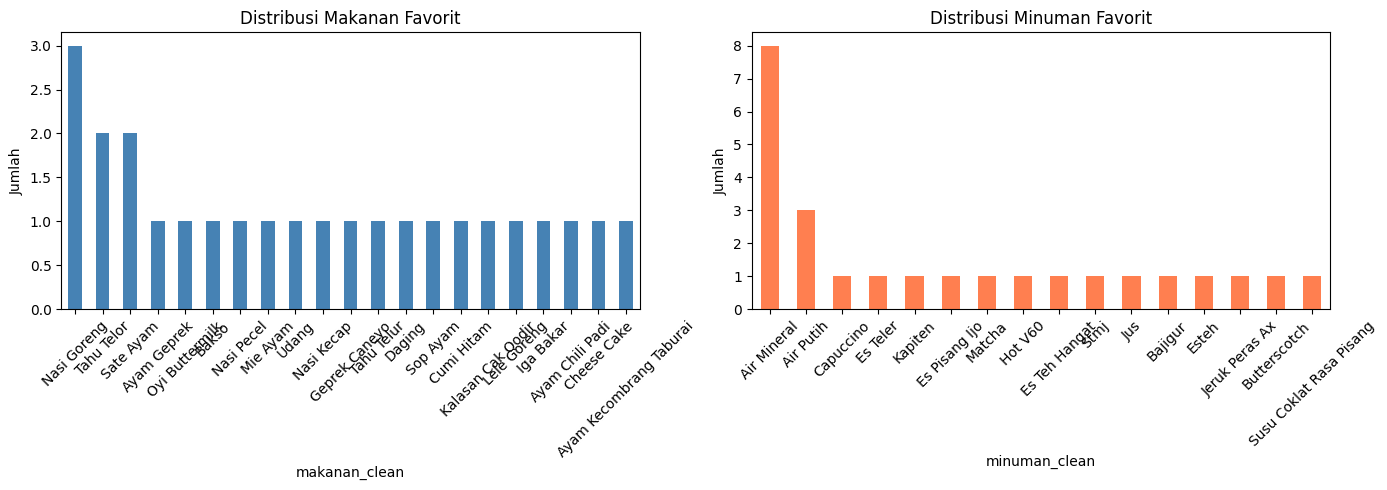

Makanan favorit saya (Nasi Goreng) : DOMINAN (Peringkat 1 terbanyak, dipilih 3 mahasiswa)
Minuman favorit saya (Air Putih)   : DOMINAN (Peringkat 2 terbanyak, dipilih 3 mahasiswa setelah Air Mineral)


In [7]:
# Jawaban Soal 5
import matplotlib.pyplot as plt

# 1. Standarisasi teks makanan & minuman
df['makanan_clean'] = df['makanan_fav'].astype(str).str.strip().str.title()
df['minuman_clean'] = df['minuman_fav'].astype(str).str.strip().str.title()

# 2. Bar Chart Distribusi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['makanan_clean'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', title='Distribusi Makanan Favorit')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

df['minuman_clean'].value_counts().plot(kind='bar', ax=axes[1], color='coral', title='Distribusi Minuman Favorit')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 3. Analisis posisi favorit
print("Makanan favorit saya (Nasi Goreng) : DOMINAN (Peringkat 1 terbanyak, dipilih 3 mahasiswa)")
print("Minuman favorit saya (Air Putih)   : DOMINAN (Peringkat 2 terbanyak, dipilih 3 mahasiswa setelah Air Mineral)")


## Soal 6
Gunakan metode **IQR (Interquartile Range)** untuk mendeteksi outlier tinggi badan.

- Apakah tinggi badanmu termasuk outlier atau tidak?

In [8]:
# Jawaban Soal 6
# 1. Hitung Q1, Q3, dan IQR
Q1 = df['tinggi_badan_(cm)'].quantile(0.25)
Q3 = df['tinggi_badan_(cm)'].quantile(0.75)
IQR = Q3 - Q1

# 2. Tentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Evaluasi tinggi badan sendiri
tb_saya = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'tinggi_badan_(cm)'].values[0]
is_outlier = (tb_saya < lower_bound) or (tb_saya > upper_bound)

print(f"Batas Bawah: {lower_bound:.2f} cm | Batas Atas: {upper_bound:.2f} cm")
print(f"Tinggi badan saya ({tb_saya} cm) -> Outlier: {'YA' if is_outlier else 'TIDAK (Normal)'}")


Batas Bawah: 137.50 cm | Batas Atas: 197.50 cm
Tinggi badan saya (180 cm) -> Outlier: TIDAK (Normal)


## Soal 7
Bersihkan kolom **Asal kelas** (hapus spasi berlebih, seragamkan huruf kapitalisasi).

- Hitung jumlah mahasiswa per kelas.
- Apakah kamu termasuk di kelas dengan jumlah terbanyak, menengah, atau sedikit?

In [10]:
# Jawaban Soal 7
# 1. Bersihkan asal kelas (hapus spasi berlebih & uppercase)
df['asal_kelas_clean'] = df['asal_kelas'].astype(str).str.strip().str.upper()

# 2. Hitung jumlah mahasiswa per kelas
count_kelas = df['asal_kelas_clean'].value_counts()
kelas_saya = df.loc[df['nama_lengkap'].str.contains('Savero', case=False), 'asal_kelas_clean'].values[0]
jml_saya = count_kelas[kelas_saya]

batas_bawah = count_kelas.quantile(0.33)
batas_atas = count_kelas.quantile(0.67)

if jml_saya > batas_atas:
    kategori = "TERBANYAK"
elif jml_saya <= batas_bawah:
    kategori = "SEDIKIT"
else:
    kategori = "MENENGAH"

print("Jumlah Mahasiswa per Kelas:\n", count_kelas)
print(f"\nBatas Sedikit: <= {batas_bawah:.1f} | Batas Terbanyak: > {batas_atas:.1f}")
print(f"Kelas saya ({kelas_saya}) : {jml_saya} mahasiswa -> Kategori: {kategori}")


Jumlah Mahasiswa per Kelas:
 asal_kelas_clean
2B    7
2C    6
2A    4
2G    3
2H    2
2F    2
2E    1
Name: count, dtype: int64

Batas Sedikit: <= 2.0 | Batas Terbanyak: > 4.0
Kelas saya (2F) : 2 mahasiswa -> Kategori: SEDIKIT
